In [6]:
import numpy as np

class RegresionLinealPesada:
    def __init__(self, tau, kernel="gaussiano", d=None):
        self.tau = tau
        self.kernel = kernel
        self.d = d  # parámetro para tricubo

    # -------------------------------
    # Definición de pesos
    # -------------------------------
    def _calcular_pesos(self, X, x_objetivo):
        dist = np.linalg.norm(X - x_objetivo, axis=1)


        """
        Calcula los pesos para cada punto en X basados en su distancia a x_objetivo.

        :param X: Matriz de datos de entrada.
        :param x_objetivo: Punto objetivo para el cual calcular los pesos.
        :return: Vector de pesos.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colosimo | Tomas Macrade
        :date: 13/06/2026
        """

        if self.kernel == "gaussiano":
            # Kernel gaussiano
            w = np.exp(-dist**2 / (2 * self.tau**2))
        elif self.kernel == "tricubo":
            # Kernel tricubo
            if self.d is None:
                raise ValueError("Debe especificar d para kernel tricubo.")
            w = (1 - (dist / self.d)**3)**3
            w[dist > self.d] = 0  # fuera del radio, peso cero
        else:
            raise ValueError("Kernel no reconocido.")

        return w

    def _entrenar(self, X, y, x_objetivo, max_iter=100, tol=1e-6,lr=0.01):

        """
        Calcula los pesos para cada punto en X basados en su distancia a x_objetivo.

        :param X: Matriz de datos de entrada.
        :param y: Vector de etiquetas.
        :param x_objetivo: Punto objetivo para el cual calcular los pesos.
        :param max_iter: Número máximo de iteraciones para el descenso de gradiente.
        :param tol: Tolerancia para la convergencia.
        :param lr: Tasa de aprendizaje para el descenso de gradiente.
        :return: Vector de parámetros ajustados.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colosimo | Tomas Macrade
        :date: 13/06/2026
        """
        w = self._calcular_pesos(X, x_objetivo)
        XtWX = X.T @ (w[:, None] * X)
        XtWy = X.T @ (w * y)
        return np.linalg.solve(XtWX, XtWy)

    def _agregar_intercepto_X(self, X):


        """
        Agrega una columna de unos a la matriz de datos para el término de intercepto.
        :param X: Matriz de datos de entrada.
        :return: Matriz de datos con columna de unos agregada.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colosimo | Tomas Macrade
        :date: 13/06/2026
        """
        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return np.column_stack([np.ones(X.shape[0]), X])

    def _agregar_intercepto_punto(self, x):
        x = np.asarray(x).ravel()
        return np.concatenate([[1.0], x])

    def predecir(self, X, y, x_objetivo):

        """
        Realiza una predicción para un punto objetivo dado utilizando regresión lineal local ponderada.
        :param X: Matriz de datos de entrada.
        :param y: Vector de etiquetas.
        :param x_objetivo: Punto objetivo para el cual realizar la predicción.
        :return: Predicción para el punto objetivo.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colosimo | Tomas Macrade
        :date: 13/06/2026
        """
        X = self._agregar_intercepto_X(X)
        x_objetivo = self._agregar_intercepto_punto(x_objetivo)
        params = self._entrenar(X, y, x_objetivo)
        return x_objetivo @ params

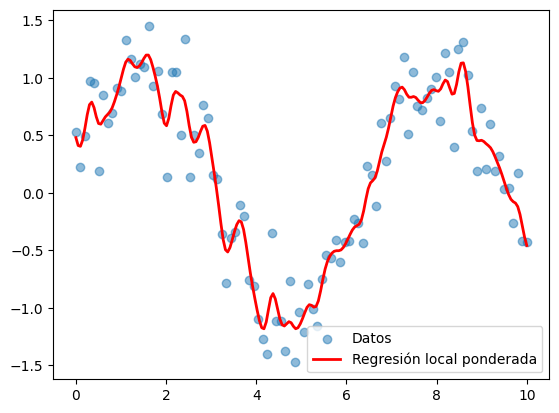

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Datos
np.random.seed(0)
x = np.linspace(0, 10, 100)
y = np.sin(x) + np.random.normal(scale=0.3, size=len(x))

# Matriz de diseño con intercepto
modelo = RegresionLinealPesada(tau=0.1)

# Puntos donde evaluar la curva
x_grid = np.linspace(x.min(), x.max(), 200)

y_pred = []

for x0 in x_grid:
    pred = modelo.predecir(x, y, x0)
    y_pred.append(pred)

y_pred = np.array(y_pred)

# Graficar
plt.scatter(x, y, alpha=0.5, label="Datos")
plt.plot(x_grid, y_pred, color="red", linewidth=2,
         label="Regresión local ponderada")

plt.legend()
plt.show()